In [6]:
import sys
import os


possible_roots = [
    "/workspaces/EV-Torque-Vectoring/src",
    os.path.abspath(os.path.join(os.getcwd(), "src")),
    os.path.abspath(os.path.join(os.getcwd(), "../src")),
    os.path.abspath(os.path.join(os.getcwd(), "../../src"))
]

added = False
for p in possible_roots:
    if os.path.exists(p):
        if p not in sys.path:
            sys.path.insert(0, p) # Put it at the beginning
        print(f"found and added: {p}")
        added = True
        break

if not added:
    print("❌ Could not find 'src'. Please run !pwd and !ls -R to find your folder.")

found and added: /workspaces/EV-Torque-Vectoring/src


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from tv_sim.tv_sim.core.utils.config import VehicleConfig
from tv_sim.tv_sim.core.models.ev_18dof import Vehicle18DOF  

from tv_sim.tv_sim.core.controllers.torque_allocator import TorqueAllocator
from tv_sim.tv_sim.core.controllers.drive_intent import ReferenceModel
from tv_sim.tv_sim.core.controllers.torque_vectoring import VehicleLQR


In [8]:
import numpy as np
def ramp_input(time_array, start_time, end_time, start_val, end_val):
    """
    Creates a smooth linear transition between two values over time.
    """
    out = np.full_like(time_array, start_val)
    mask = (time_array >= start_time) & (time_array <= end_time)
    
    # Linear interpolation
    if end_time > start_time:
        fraction = (time_array[mask] - start_time) / (end_time - start_time)
        out[mask] = start_val + (end_val - start_val) * fraction
        
    # Hold the final value after end_time
    out[time_array > end_time] = end_val
    return out

def trapezoidal_input(time_array, t_start, t_rise, t_fall, t_end, peak_val):
    """
    Useful for throttle: Smoothly ramps up, holds, and ramps down.
    """
    # Rise
    val = ramp_input(time_array, t_start, t_rise, 0.0, peak_val)
    # Fall (overwrites the hold value)
    mask_fall = time_array > t_fall
    val[mask_fall] = ramp_input(time_array[mask_fall], t_fall, t_end, peak_val, 0.0)
    return val



def run_simulation(cfg, throttle_profile, steer_profile, T_MAX=60.0, DT=0.002, controller_dt=0.05,controller_use=False):
    """
    Simulates the 18-DOF vehicle dynamics with internal sub-stepping 
    for tire stability.
    """

    steps = int(T_MAX / DT)
    time_array = np.linspace(0, T_MAX, steps)
    
    vehicle = Vehicle18DOF(cfg) 
    if controller_use:

        tires=vehicle.tires.values()
        controller=VehicleLQR(cfg,dt=controller_dt)




    reference = ReferenceModel(cfg)
    torque_allocator = TorqueAllocator(cfg)
    
    history = []
    last_execution_controller = -controller_dt 
    mz_request = 0.0

    print(f"Starting reliable simulation: {T_MAX}s, DT={DT}...")

    for i in range(steps):
        t = time_array[i]
        delta = steer_profile[i]
        throttle_request = throttle_profile[i]
        
        # State extraction
        vx = vehicle.state[0]
        vy=vehicle.state[1]
        actual_yaw_rate = vehicle.state[2]
        target_yaw = reference.get_target_yaw_rate(vx, delta)
        # Control
        if(controller_use):
            if (t - last_execution_controller) >= (controller_dt - 1e-9):
                # Target yaw rate based on steering and speed
                mz_request = controller.solve(vx, vy, actual_yaw_rate, delta,reference.get_target_yaw_rate)
                last_execution_controller = t
                
       
        torques = torque_allocator.distribute(throttle_request, mz_request, DT)
        
        # Physics
        state = vehicle.step(torques, delta, DT,substeps=10)
        
        # Logging
        beta = np.arctan2(state[1], max(state[0], 0.1))
        
        # 21 Columns: [0:18 States, 18: Delta, 19: Beta, 20: Mz_req]
        record = np.zeros(22)
        record[0:18] = state
        record[18]   = delta
        record[19]   = beta
        record[20]   = mz_request
        record[21]  =   target_yaw
        
        history.append(record)

    return time_array, np.array(history)

In [9]:

T_MAX = 60.0       
DT = 0.02         
steps = int(T_MAX / DT)
time = np.linspace(0, T_MAX, steps)

# Generate Profiles

throttle_profile = trapezoidal_input(time, 0.0, 0.5, 25.0, 25.1, 0.1)

steer_profile = ramp_input(time, 10.0, 15.0, 0.0, np.radians(10))

# Initialize your configuration
cfg = VehicleConfig() 


# Run the wrapper

time, data = run_simulation(
    cfg, 
    throttle_profile, 
    steer_profile, 
    T_MAX=T_MAX, 
    DT=DT, 
    controller_dt=0.05,controller_use=True
)

Starting reliable simulation: 60.0s, DT=0.02...


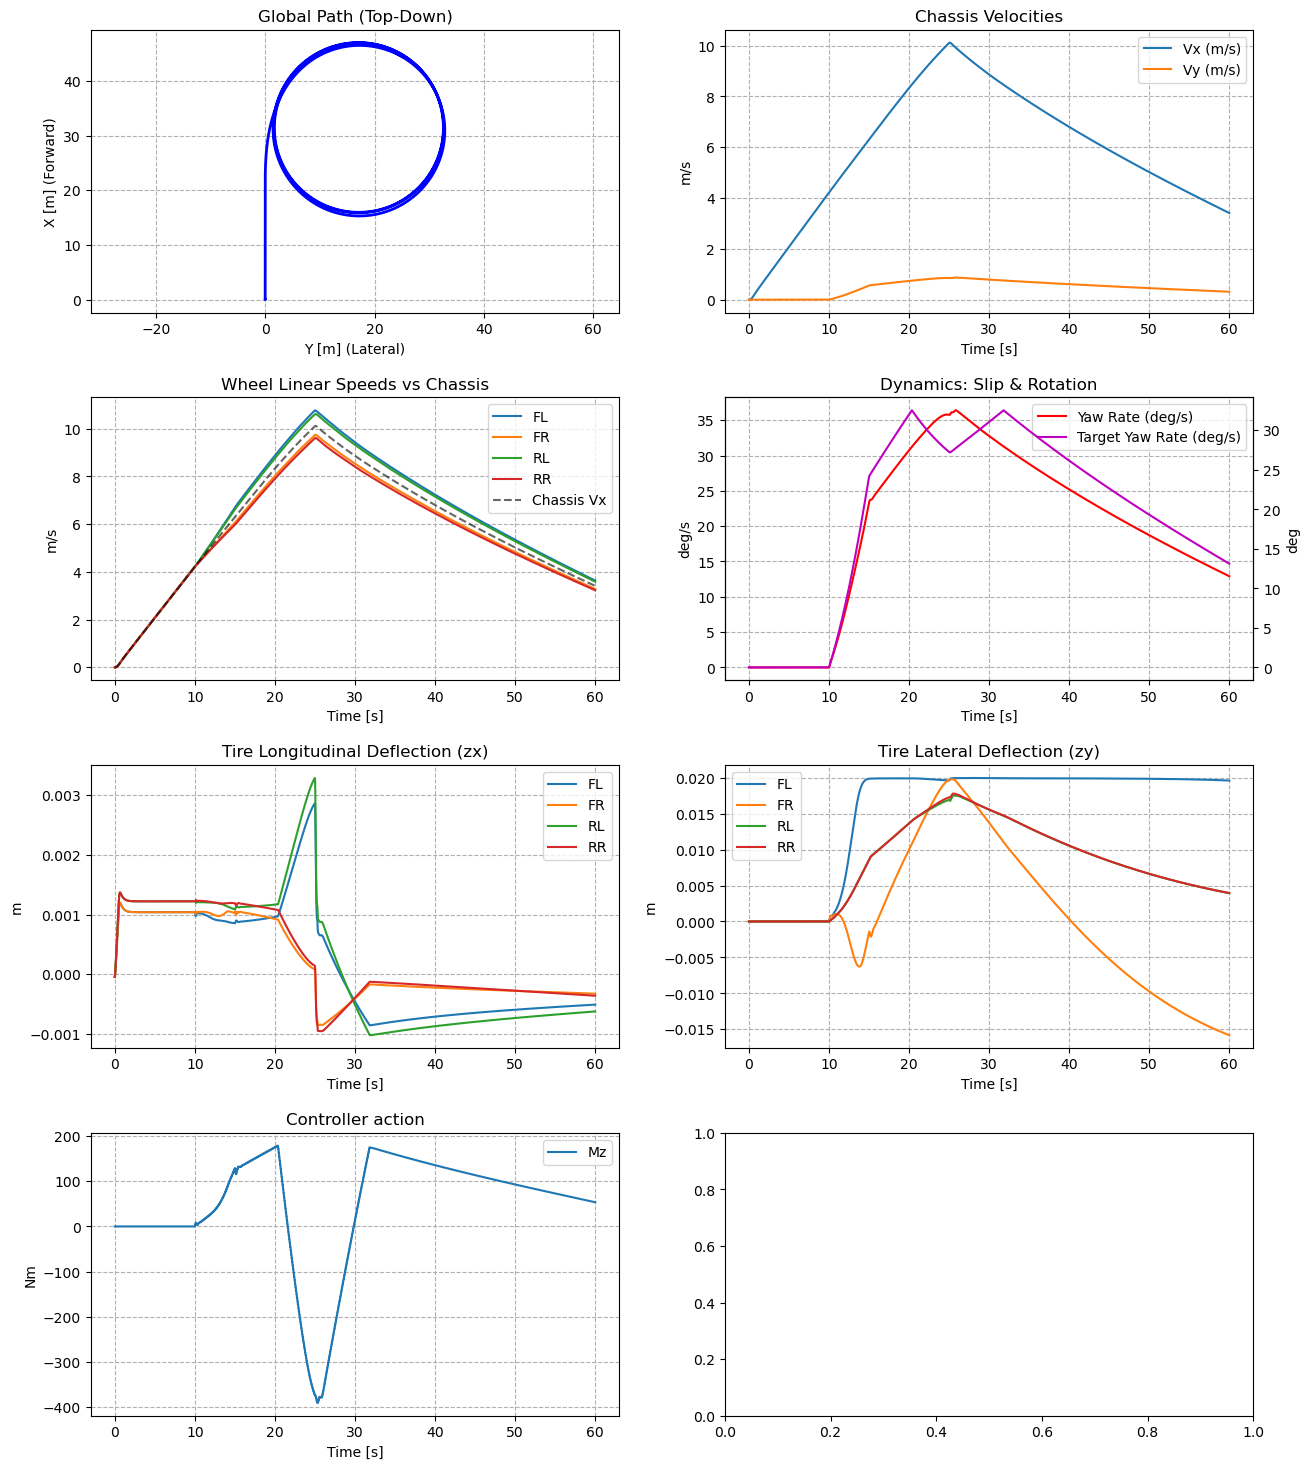

In [10]:
import matplotlib.pyplot as plt

def plot_simulation_results(time, data):
    """
    Plots the 18-DOF Vehicle Dynamics results.
    Data mapping assumes:
    0-2: vx, vy, r | 3-5: x, y, psi | 6-9: w1-4
    10-13: zx | 14-17: zy | 18: delta | 19: beta | 20: mz_req
    """
    fig, axs = plt.subplots(4, 2, figsize=(15, 18))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    
    # --- 1. Global Path (Top-Down) ---
    axs[0, 0].plot(data[:, 4], data[:, 3], 'b', lw=2)
    axs[0, 0].set_title("Global Path (Top-Down)")
    axs[0, 0].set_xlabel("Y [m] (Lateral)")
    axs[0, 0].set_ylabel("X [m] (Forward)")
    axs[0, 0].axis('equal')
    axs[0, 0].grid(True, ls='--')

    # --- 2. Chassis Velocities ---
    axs[0, 1].plot(time, data[:, 0], label="Vx (m/s)")
    axs[0, 1].plot(time, data[:, 1], label="Vy (m/s)")
    axs[0, 1].set_title("Chassis Velocities")
    axs[0, 1].set_xlabel("Time [s]")
    axs[0, 1].set_ylabel("m/s")
    axs[0, 1].legend()
    axs[0, 1].grid(True, ls='--')

    # --- 3. Wheel vs Chassis Speeds ---
    labels = ['FL', 'FR', 'RL', 'RR']
    for i in range(4):
        axs[1, 0].plot(time, data[:, 6+i] * cfg.Re, label=labels[i]) # Assuming cfg is accessible
    axs[1, 0].plot(time, data[:, 0], 'k--', alpha=0.6, label="Chassis Vx")
    axs[1, 0].set_title("Wheel Linear Speeds vs Chassis")
    axs[1, 0].set_xlabel("Time [s]")
    axs[1, 0].set_ylabel("m/s")
    axs[1, 0].legend()
    axs[1, 0].grid(True, ls='--')

    # --- 4. Dynamics: Slip & Rotation ---
    ax_yaw = axs[1, 1]
    ax_beta = ax_yaw.twinx()
    ln1 = ax_yaw.plot(time, np.degrees(data[:, 2]), 'r', label="Yaw Rate (deg/s)")
    ln2 = ax_beta.plot(time, np.degrees(data[:, 21]), 'm', label="Target Yaw Rate (deg/s)")
    #ln2 = ax_beta.plot(time, np.degrees(data[:, 19]), 'm', label="Beta (Slip Angle)")
    ax_yaw.set_title("Dynamics: Slip & Rotation")
    ax_yaw.set_xlabel("Time [s]")
    ax_yaw.set_ylabel("deg/s")
    ax_beta.set_ylabel("deg")
    
    # Combined legend for twin axes
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax_yaw.legend(lns, labs, loc=0)
    ax_yaw.grid(True, ls='--')

    # --- 5. Tire Longitudinal Deflection (zx) ---
    for i in range(4):
        axs[2, 0].plot(time, data[:, 10+i], label=labels[i])
    axs[2, 0].set_title("Tire Longitudinal Deflection (zx)")
    axs[2, 0].set_xlabel("Time [s]")
    axs[2, 0].set_ylabel("m")
    axs[2, 0].legend()
    axs[2, 0].grid(True, ls='--')

    # --- 6. Tire Lateral Deflection (zy) ---
    for i in range(4):
        axs[2, 1].plot(time, data[:, 14+i], label=labels[i])
    axs[2, 1].set_title("Tire Lateral Deflection (zy)")
    axs[2, 1].set_xlabel("Time [s]")
    axs[2, 1].set_ylabel("m")
    axs[2, 1].legend()
    axs[2, 1].grid(True, ls='--')

  

  
    axs[3, 0].plot(time, data[:, 20], label='Mz')
    axs[3, 0].set_title("Controller action")
    axs[3, 0].set_xlabel("Time [s]")
    axs[3, 0].set_ylabel("Nm")
    axs[3, 0].legend()
    axs[3, 0].grid(True, ls='--')

    plt.show()

# Usage:
plot_simulation_results(time, data)